# Error analysis

In [1]:
import logging
import pandas as  pd
log_file=r"C:\Users\davro\OneDrive\Desktop\git_project\log\error_analysis.log"

In [2]:
logging.basicConfig(
    filename=log_file,
    filemode='a',
    level=logging.INFO,
    format="%(asctime)s-%(levelname)s-%(message)s"
)
logging.info('Analysis started!')

In [3]:
import os
import sys
sys.path.append(r"C:\Users\davro\OneDrive\Desktop\git_project\src")

In [4]:
from data_loader import DataLoader

In [5]:
path=r"C:\Users\davro\OneDrive\Desktop\git_project\Data\Raw_Data"
loading=DataLoader(path)



In [115]:
df=loading.load_datasets()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20926 entries, 0 to 20925
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            20926 non-null  int64  
 1   player_name   20926 non-null  object 
 2   games         20926 non-null  int64  
 3   time          20926 non-null  int64  
 4   goals         20926 non-null  int64  
 5   xG            20926 non-null  float64
 6   assists       20926 non-null  int64  
 7   xA            20926 non-null  float64
 8   shots         20926 non-null  int64  
 9   key_passes    20926 non-null  int64  
 10  yellow_cards  20926 non-null  int64  
 11  red_cards     20926 non-null  int64  
 12  position      20926 non-null  object 
 13  team_title    20926 non-null  object 
 14  npg           20926 non-null  int64  
 15  npxG          20926 non-null  float64
 16  xGChain       20926 non-null  float64
 17  xGBuildup     20926 non-null  float64
 18  league        20926 non-nu

In [43]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [57]:
num_col = df.select_dtypes(include=[np.number]).columns.drop('xG').tolist()
cat_col = df.select_dtypes(exclude=[np.number]).columns.tolist()

In [58]:
for col in cat_col:
    df[col]=df[col].astype(str)

In [59]:
if 'xG' not in df.columns:
    print("⚠️ Column 'xG' not found. Available columns are:")
    print(df.columns.tolist())
else:
    
    X = df.drop('xG', axis=1)
    y = df['xG']

In [60]:
num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',MinMaxScaler())

])

In [61]:
num_pipeline

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', MinMaxScaler())])

In [62]:
cat_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])

In [63]:
cat_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1))])

In [64]:
preprocessor=ColumnTransformer([
    
        ('num',num_pipeline,num_col),
        ('cat',cat_pipeline,cat_col)
    
])

In [65]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', MinMaxScaler())]),
                                 ['id', 'games', 'time', 'goals', 'assists',
                                  'xA', 'shots', 'key_passes', 'yellow_cards',
                                  'red_cards', 'npg', 'npxG', 'xGChain',
                                  'xGBuildup']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['player_name', 'position', 'team_title',
                                  'league', 'season'])])

In [66]:
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor(random_state=42))
])

In [67]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['id', 'games', 'time',
                                                   'goals', 'assists', 'xA',
                                                   'shots', 'key_passes',
                                                   'yellow_cards', 'red_cards',
                                                   'npg', 'npxG', 'xGChain',
                                                   'xGBuildup']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['player_name', 'position',
                                                   'team_title', 'league',
                                                   'season'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [68]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [69]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['id', 'games', 'time',
                                                   'goals', 'assists', 'xA',
                                                   'shots', 'key_passes',
                                                   'yellow_cards', 'red_cards',
                                                   'npg', 'npxG', 'xGChain',
                                                   'xGBuildup']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['player_name', 'position',
                                                   'team_title', 'league',
                                                   'season'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [70]:
y_pred = pipeline.predict(x_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

In [77]:

print(f"r2 is {r2:.2f}")
print(f"mae is  {mae:.2f}")


r2 is 0.98
mae is  0.15


# Error analysis

In [92]:
# Calculate erors and make a table 
errors = y_test - y_pred
abs_errors = np.abs(errors)

In [79]:
error_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Error': errors,
    'Absolute Error': abs_errors
})


In [80]:
error_df = error_df.reset_index(drop=True)
x_test_reset = x_test.reset_index(drop=True)

In [89]:
error_analysis_df = pd.concat([x_test_reset, error_df], axis=1)

In [91]:
print("Error DataFrame created successfully!")
error_analysis_df.head()

Error DataFrame created successfully!


,id,player_name,games,time,goals,assists,xA,shots,key_passes,yellow_cards,...,npg,npxG,xGChain,xGBuildup,league,season,Actual,Predicted,Error,Absolute Error
0,540,Darren Randolph,3,270,0,0,0.000000,0,0,0,...,0,0.000000,0.275162,0.275162,PremierLeague,2021,0.000000,0.000000,0.000000,0.000000
1,2128,David Juncà,9,684,0,2,0.483820,4,6,1,...,0,0.147809,1.237589,0.715679,LaLiga,1617,0.147809,0.147726,0.000083,0.000083
2,2226,Zaldúa,30,2562,1,0,2.042418,11,15,9,...,1,0.407314,4.943093,3.633635,LaLiga,1718,0.407314,0.407132,0.000182,0.000182
3,6991,Leo Stulac,8,294,1,2,0.246994,3,6,1,...,1,0.095799,0.574138,0.359831,ASerie,2122,0.095799,0.095987,-0.000189,0.000189
4,338,Max Meyer,17,641,0,0,0.198000,9,4,1,...,0,0.459281,0.856348,0.379644,PremierLeague,1920,0.459281,0.459313,-0.000032,0.000032


In [98]:
error_cols = error_analysis_df[['player_name','Error', 'Absolute Error']]
print(error_cols.head(10))



         player_name     Error  Absolute Error
0    Darren Randolph  0.000000        0.000000
1        David Juncà  0.000083        0.000083
2             Zaldúa  0.000182        0.000182
3         Leo Stulac -0.000189        0.000189
4          Max Meyer -0.000032        0.000032
5    William Buckley -0.008187        0.008187
6      Thomas Müller  1.826746        1.826746
7  Grégory Bourillon -0.007863        0.007863
8          Joe Bryan -0.159972        0.159972
9     Marcell Jansen -0.006078        0.006078


In [99]:
# Worst Predictions

In [100]:
# 4️⃣ Sort by largest absolute errors
worst_predictions = error_analysis_df.sort_values(by='Absolute Error', ascending=False).head(10)

print("🔎 Top 10 Worst Predictions:")
display(worst_predictions[['Actual', 'Predicted', 'Error', 'Absolute Error']])


🔎 Top 10 Worst Predictions:


,Actual,Predicted,Error,Absolute Error
2924,15.226494,11.284354,3.942140,3.942140
4151,21.232019,17.545071,3.686948,3.686948
535,28.050517,24.407995,3.642522,3.642522
3162,35.589006,32.179597,3.409409,3.409409
2752,10.777041,7.394235,3.382807,3.382807
3073,12.368610,8.990674,3.377936,3.377936
2623,21.575576,18.218772,3.356805,3.356805
3825,7.149527,3.874023,3.275504,3.275504
2272,21.097412,17.872741,3.224671,3.224671
4154,14.725130,11.540541,3.184589,3.184589


In [101]:
# Error distributions

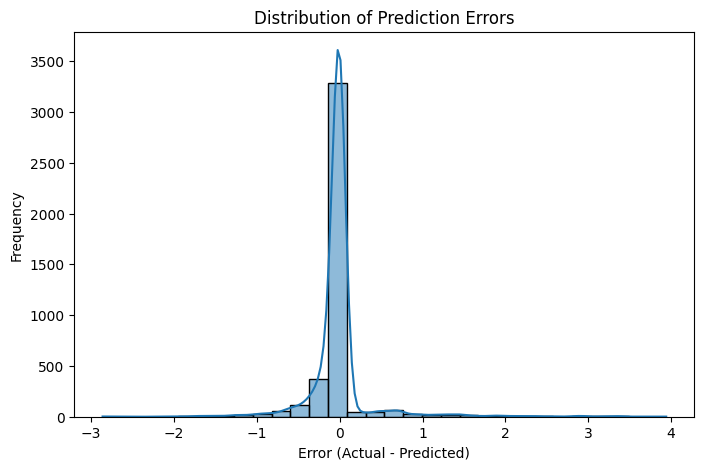

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns 
plt.figure(figsize=(8, 5))
sns.histplot(errors, bins=30, kde=True)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()


In [108]:
#Actual vs Predicted


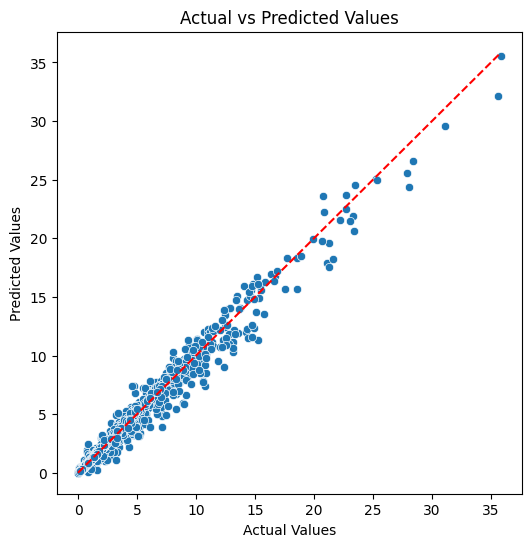

In [109]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20926 entries, 0 to 20925
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            20926 non-null  int64  
 1   player_name   20926 non-null  object 
 2   games         20926 non-null  int64  
 3   time          20926 non-null  int64  
 4   goals         20926 non-null  int64  
 5   xG            20926 non-null  float64
 6   assists       20926 non-null  int64  
 7   xA            20926 non-null  float64
 8   shots         20926 non-null  int64  
 9   key_passes    20926 non-null  int64  
 10  yellow_cards  20926 non-null  int64  
 11  red_cards     20926 non-null  int64  
 12  position      20926 non-null  object 
 13  team_title    20926 non-null  object 
 14  npg           20926 non-null  int64  
 15  npxG          20926 non-null  float64
 16  xGChain       20926 non-null  float64
 17  xGBuildup     20926 non-null  float64
 18  league        20926 non-nu